<a href="https://colab.research.google.com/github/hoc-sinh-guong-mau/Machine-Learning/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Random Forrest**


##1. Loading data

In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zeeshier/weather-forecast-dataset")

print("Path to dataset files:", path)

100%|██████████| 114k/114k [00:00<00:00, 29.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zeeshier/weather-forecast-dataset/versions/1


##2. Preprocessing data và EDA

###2.1 Tổng quát

In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_name = 'weather_forecast_data.csv'
csv_file_path = os.path.join(path, csv_file_name)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print("DataFrame 'df' loaded successfully.\n")

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget unique values:")
print(df["Rain"].unique())

DataFrame 'df' loaded successfully.

Shape: (2500, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
None

First 5 rows:
   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.8

- Dataset được lựa chọn có kích thước 2500 records và 6 biến thuộc tính: Điều này cho thấy đây là một bộ dữ liệu có quy mô vừa phải, đủ để triển khai các mô hình học máy trung cấp mà không quá nặng về tài nguyên tính toán.
- Biến:
  + biến thuộc tính: 5 biến thuộc tính là biến định lượng.
  + biến mục tiêu: biến phân loại nhị phân rain có 2 giá trị duy nhất là "rain" và "no rain"
=> Điều này cho thấy bộ dữ liệu này phù hợp để hiện thực các tác vụ học máy phân loại (Classification). Tuy nhiên cần phải mã hóa (Encoding) các biến mục tiêu để huấn luyện và đánh giá.
- Mức độ hoàn chỉnh của dữ liệu:
  + Dữ liệu thiếu (Missing value): Thống kê mô tả cho thấy bộ dữ liệu hoàn toàn không có dữ liệu bị thiếu, tránh được việc điền khuyết dữ liệu gây ra sai lệch do nội suy hay loại bỏ quan sát.
  + Dữ liệu trùng lập (Duplicate value): Dataset không có bản ghi trùng lặp, nghĩa là mỗi dòng dữ liệu có thể được xem là một quan sát độc lập. Điều này giúp tăng độ tin cậy cho quá trình huấn luyện và đánh giá mô hình.

###2.2 Phân tích biến mục tiêu(Rain)

In [ ]:
print("Target Variable: Rain\n")
print("Value: ")
print(df["Rain"].unique())
print("\nDistribution: ")
print(df["Rain"].value_counts())
print("\nDistribution (%):")
print((df["Rain"].value_counts(normalize=True) * 100).round(2))
majority_class_ratio = df["Rain"].value_counts(normalize=True).max()
print(f"\nBaseline accuracy if always predict majority class: {majority_class_ratio:.4f}")

Target Variable: Rain

Value: 
['rain' 'no rain']

Distribution: 
Rain
no rain    2186
rain        314
Name: count, dtype: int64

Distribution (%):
Rain
no rain    87.44
rain       12.56
Name: proportion, dtype: float64

Baseline accuracy if always predict majority class: 0.8744


Biến mục tiêu của bộ dữ liệu là Rain, bao gồm hai giá trị phân loại là "rain" và "no rain", cho thấy bài toán thuộc nhóm phân loại nhị phân. Kết quả thống kê cho thấy phân bố của biến mục tiêu không đồng đều giữa hai lớp, trong đó lớp no rain chiếm 2186 quan sát, tương đương 87.44%, trong khi lớp rain chỉ chiếm 314 quan sát, tương đương 12.56%. Điều này cho thấy bộ dữ liệu tồn tại hiện tượng mất cân bằng lớp khá rõ rệt.

Sự mất cân bằng này có ý nghĩa quan trọng đối với quá trình xây dựng mô hình. Nếu chỉ sử dụng độ chính xác tổng thể làm thước đo, mô hình có thể đạt kết quả cao ngay cả khi chỉ dự đoán phần lớn mẫu thuộc lớp no rain. Do đó, trong nghiên cứu này cần sử dụng các chỉ số đánh giá phù hợp hơn như precision, recall, F1-score và ROC-AUC, đồng thời áp dụng các chiến lược chia dữ liệu có phân tầng nhằm bảo đảm tính đại diện của từng lớp trong quá trình huấn luyện và đánh giá. Ngoài ra, các kỹ thuật xử lý mất cân bằng như class weight hoặc oversampling cũng có thể được xem xét để cải thiện khả năng dự đoán lớp rain.

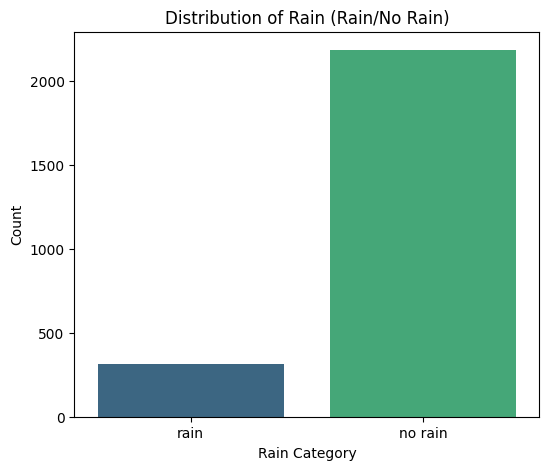

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.countplot(
    x='Rain',
    hue='Rain',
    data=df,
    palette='viridis',
    legend=False
)

plt.title('Distribution of Rain (Rain/No Rain)')
plt.xlabel('Rain Category')
plt.ylabel('Count')

plt.show()

###2.3 Phân tích biến thuộc tính

In [ ]:
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Create statistics table
stats = pd.DataFrame({
    "min": numeric_df.min(),
    "max": numeric_df.max(),
    "range": numeric_df.max() - numeric_df.min(),
    "median": numeric_df.median(),
    "Q1": numeric_df.quantile(0.25),
    "Q3": numeric_df.quantile(0.75),
})

# Interquartile Range
stats["IQR"] = stats["Q3"] - stats["Q1"]

print("Statistics for each feature:")
display(stats)

Statistics for each feature:


,min,max,range,median,Q1,Q3,IQR
Temperature,10.001842,34.995214,24.993372,22.536448,16.359398,28.976476,12.617078
Humidity,30.005071,99.997481,69.992410,63.920797,47.339815,81.561021,34.221206
Wind_Speed,0.009819,19.999132,19.989313,9.908572,4.761909,14.948408,10.186499
Cloud_Cover,0.015038,99.997795,99.982757,49.488284,23.900016,75.324140,51.424124
Pressure,980.014486,1049.985593,69.971107,1013.433035,996.938630,1031.735067,34.796437


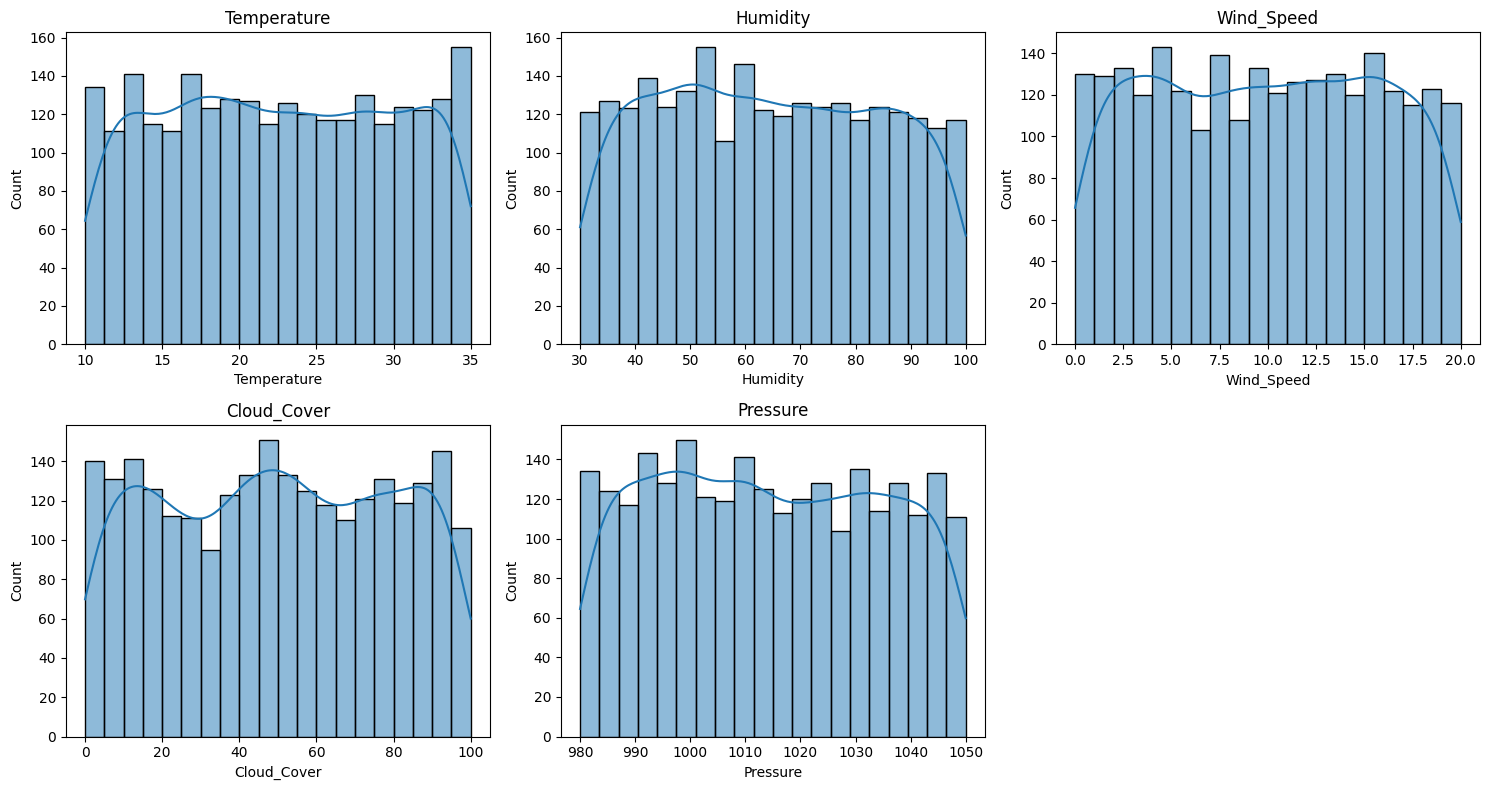

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, kde=True, bins=20, ax=axes[i])
    axes[i].set_title(col)

# Ẩn ô thừa
for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

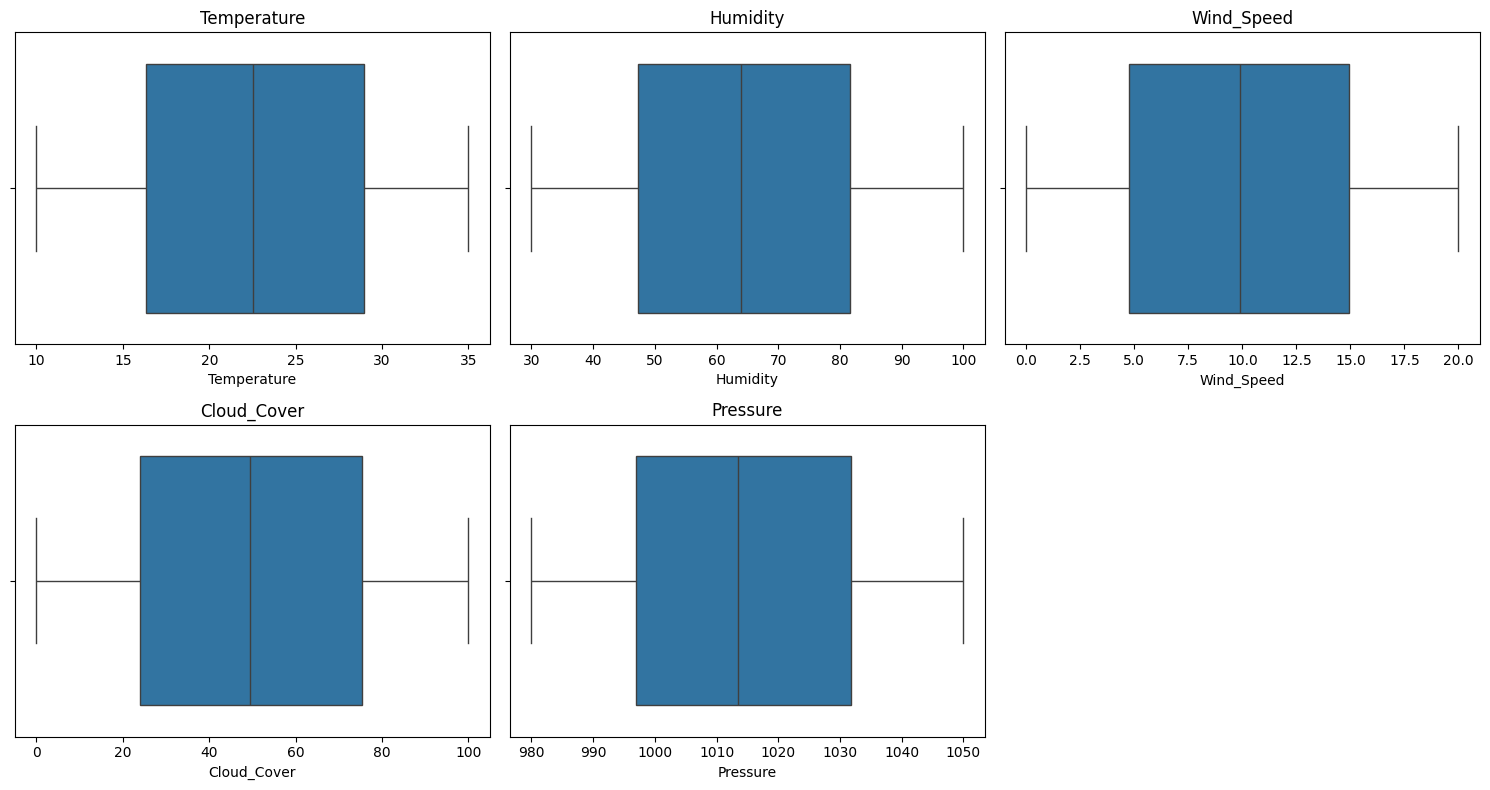

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

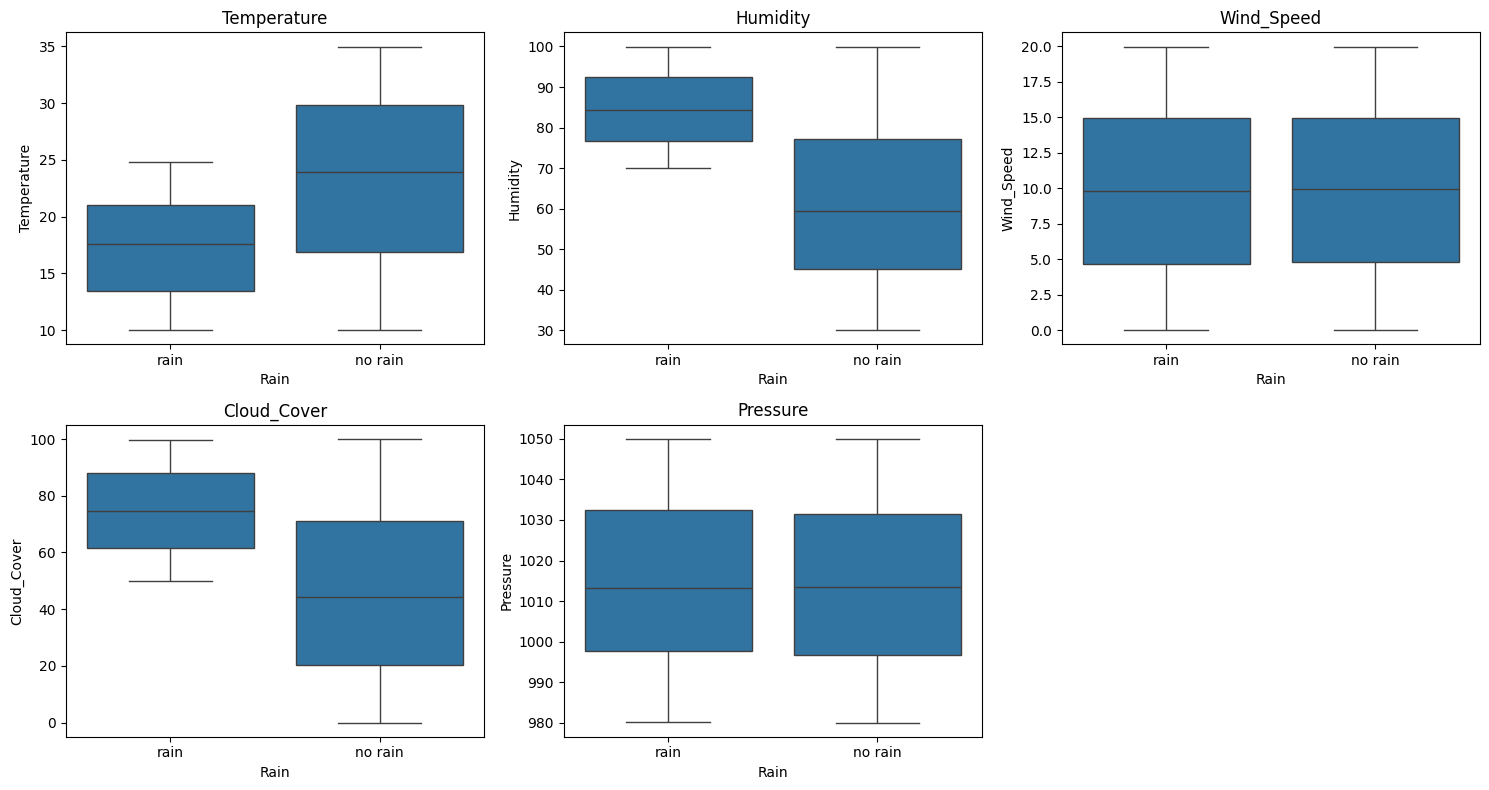

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x="Rain", y=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

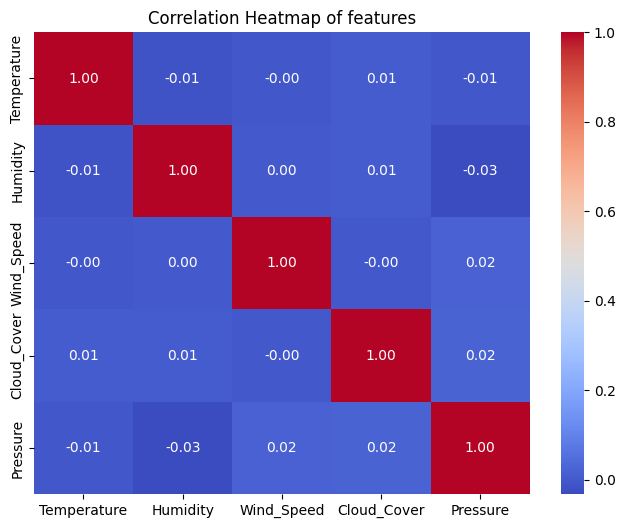

In [ ]:
df_feature = df.copy()


feature_cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure"]
corr_matrix = df_feature[feature_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of features")
plt.show()

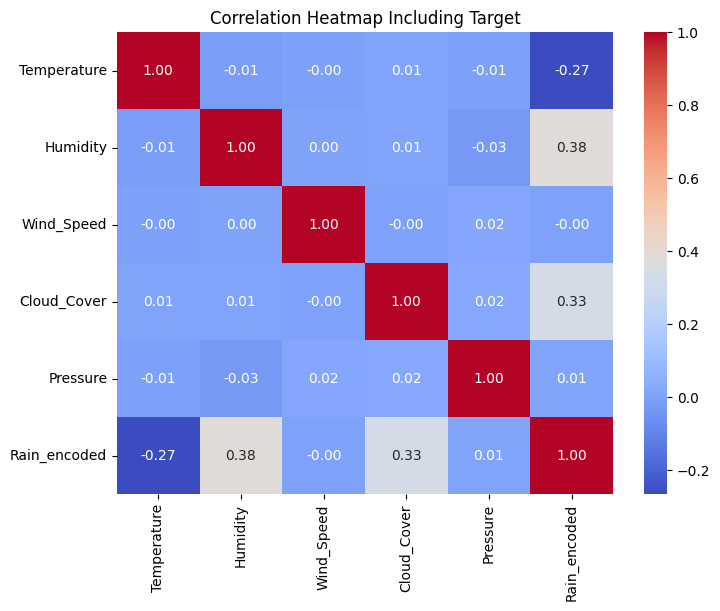

In [ ]:
df_heat = df.copy()
df_heat["Rain_encoded"] = df_heat["Rain"].map({"no rain": 0, "rain": 1})

cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure", "Rain_encoded"]
corr_matrix = df_heat[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Including Target")
plt.show()

##3. Tiền xử lý data

In [ ]:
import pandas as pd

df_rf = df.copy()

# Encode target
df_rf["Rain"] = df_rf["Rain"].map({"no rain": 0, "rain": 1})

# Kiểm tra
print(df_rf["Rain"].value_counts())
print("Missing after encoding:", df_rf["Rain"].isnull().sum())

feature_cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure"]
X = df_rf[feature_cols]
y = df_rf["Rain"]

print("X shape:", X.shape)
print("y shape:", y.shape)

Rain
0    2186
1     314
Name: count, dtype: int64
Missing after encoding: 0
X shape: (2500, 5)
y shape: (2500,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train shape: (2000, 5)
Test shape: (500, 5)

Train class distribution:
Rain
0    0.8745
1    0.1255
Name: proportion, dtype: float64

Test class distribution:
Rain
0    0.874
1    0.126
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]


rf_baseline = RandomForestClassifier(
    random_state=42
)

print(rf_baseline)

RandomForestClassifier(random_state=42)


In [ ]:
start_time = time.time()

cv_results = cross_validate(
    rf_baseline,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

end_time = time.time()
baseline_cv_time = end_time - start_time

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")
print("Balanced CV time:", baseline_cv_time, "(s)")

accuracy: 0.9990 ± 0.0020
precision: 1.0000 ± 0.0000
recall: 0.9920 ± 0.0160
f1: 0.9959 ± 0.0082
roc_auc: 1.0000 ± 0.0000
Balanced CV time: 12.733432054519653 (s)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

print(rf_balanced)

RandomForestClassifier(class_weight='balanced', random_state=42)


In [ ]:
from sklearn.metrics import confusion_matrix

start_time = time.time()

cv_results_bal = cross_validate(
    rf_balanced,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

end_time = time.time()
balanced_cv_time = end_time - start_time

for metric in scoring:
    scores = cv_results_bal[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")
print("Balanced CV time:", balanced_cv_time, "(s)")

accuracy: 0.9990 ± 0.0020
precision: 1.0000 ± 0.0000
recall: 0.9920 ± 0.0160
f1: 0.9959 ± 0.0082
roc_auc: 1.0000 ± 0.0000
Balanced CV time: 6.610790014266968 (s)


In [ ]:
cv_compare_df = pd.DataFrame({
    "Model": ["RF Baseline", "RF Balanced"],
    "CV Accuracy": [
        cv_results["test_accuracy"].mean(),
        cv_results_bal["test_accuracy"].mean()
    ],
    "CV Precision": [
        cv_results["test_precision"].mean(),
        cv_results_bal["test_precision"].mean()
    ],
    "CV Recall": [
        cv_results["test_recall"].mean(),
        cv_results_bal["test_recall"].mean()
    ],
    "CV F1": [
        cv_results["test_f1"].mean(),
        cv_results_bal["test_f1"].mean()
    ],
    "CV ROC-AUC": [
        cv_results["test_roc_auc"].mean(),
        cv_results_bal["test_roc_auc"].mean()
    ],
    "CV Time (s)": [
        baseline_cv_time,
        balanced_cv_time
    ]
})

cv_compare_df.round(4)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,CV Time (s)
0,RF Baseline,0.999,1.0,0.992,0.9959,1.0,12.7334
1,RF Balanced,0.999,1.0,0.992,0.9959,1.0,6.6108


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_rf.fit(X_train, y_train)
end_time = time.time()
grid_search_time = end_time - start_time

print("Best parameters:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)
print("Grid search time:", grid_search_time, "(s)")

Fitting 10 folds for each of 54 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9959183673469388
Grid search time: 237.85021710395813 (s)


In [ ]:
results = pd.DataFrame(grid_rf.cv_results_)
display(results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.484384,0.023268,0.019312,0.000959,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
1,1.062500,0.321520,0.040886,0.015579,None,1,2,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
2,1.292644,0.381659,0.058291,0.026410,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
3,2.167041,0.450737,0.078395,0.026835,None,1,5,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
4,1.506528,0.226393,0.059566,0.014976,None,1,10,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
5,1.964868,0.564874,0.072758,0.041037,None,1,10,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
6,0.500844,0.068470,0.020051,0.004455,None,2,2,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
7,1.131298,0.340042,0.040546,0.013702,None,2,2,200,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
8,0.526574,0.107861,0.018739,0.000951,None,2,5,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1
9,0.901806,0.021123,0.030824,0.001380,None,2,5,200,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",1.0,...,1.0,1.0,1.0,1.0,1.0,0.979592,1.0,0.995918,0.008163,1


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time

best_rf = grid_rf.best_estimator_

start_time = time.time()

cv_results_final = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

end_time = time.time()
best_cv_time = end_time - start_time

for metric in scoring:
    scores = cv_results_final[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")
print("Balanced CV time:", best_cv_time, "(s)")

accuracy: 0.9990 ± 0.0020
precision: 1.0000 ± 0.0000
recall: 0.9920 ± 0.0160
f1: 0.9959 ± 0.0082
roc_auc: 1.0000 ± 0.0000
Balanced CV time: 2.5834009647369385 (s)


In [ ]:

print("Best Random Forest model:")
print(best_rf)

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, zero_division=0)
test_recall = recall_score(y_test, y_pred, zero_division=0)
test_f1 = f1_score(y_test, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_prob)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC-AUC:", test_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Random Forest model:
RandomForestClassifier(class_weight='balanced', random_state=42)
Test Accuracy: 1.0
Test Precision: 1.0
Test Recall: 1.0
Test F1-score: 1.0
Test ROC-AUC: 1.0

Confusion Matrix:
[[437   0]
 [  0  63]]


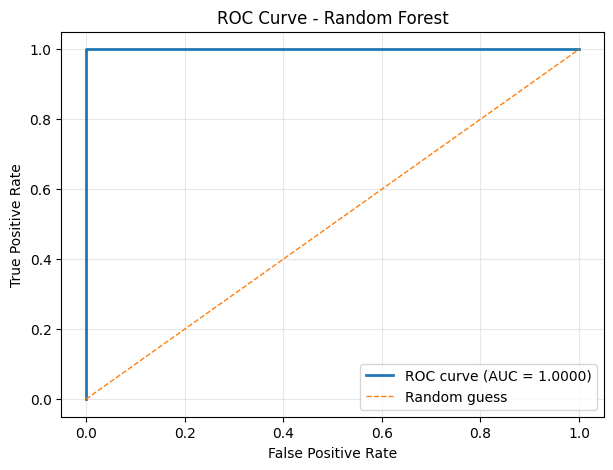

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# =========================
# ROC Curve
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()



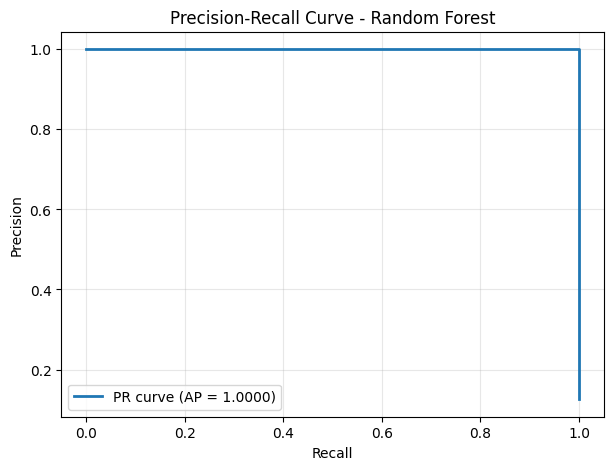

In [ ]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2, label=f'PR curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

       Feature  Importance
1     Humidity    0.447342
3  Cloud_Cover    0.321863
0  Temperature    0.220801
4     Pressure    0.005272
2   Wind_Speed    0.004721


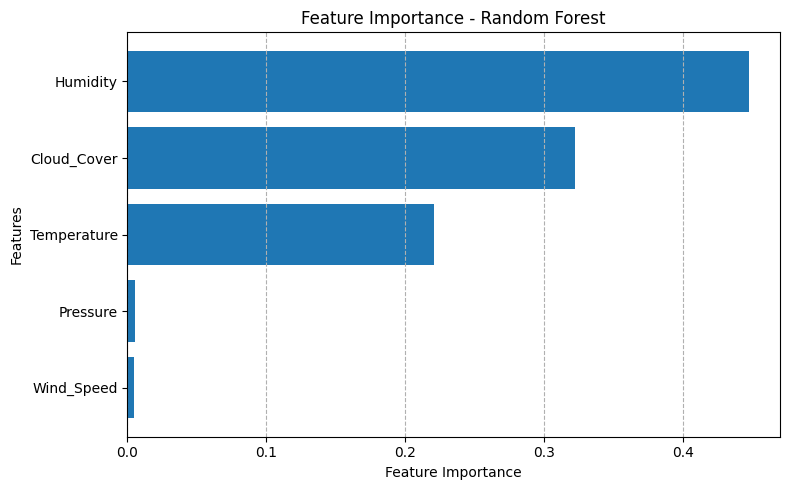

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Dữ liệu của bạn
data = {
    "Feature": ["Humidity", "Cloud_Cover", "Temperature", "Pressure", "Wind_Speed"],
    "Importance": [0.447342, 0.321863, 0.220801, 0.005272, 0.004721]
}

df = pd.DataFrame(data)

# Sắp xếp giảm dần (đẹp hơn khi vẽ)
df = df.sort_values(by="Importance", ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.barh(df["Feature"], df["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.grid(axis='x', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()

In [ ]:
rf_summary = pd.DataFrame({
    "Model": ["RF Baseline", "RF Balanced", "RF Tuned Final"],
    "Accuracy": [
        cv_results["test_accuracy"].mean(),
        cv_results_bal["test_accuracy"].mean(),
        test_accuracy
    ],
    "Precision": [
        cv_results["test_precision"].mean(),
        cv_results_bal["test_precision"].mean(),
        test_precision
    ],
    "Recall": [
        cv_results["test_recall"].mean(),
        cv_results_bal["test_recall"].mean(),
        test_recall
    ],
    "F1-score": [
        cv_results["test_f1"].mean(),
        cv_results_bal["test_f1"].mean(),
        test_f1
    ],
    "ROC-AUC": [
        cv_results["test_roc_auc"].mean(),
        cv_results_bal["test_roc_auc"].mean(),
        test_roc_auc
    ],
    "CV Time (s)": [
        baseline_cv_time,
        balanced_cv_time,
        np.nan
    ],
    "Tuning Time (s)": [
        np.nan,
        np.nan,
        grid_search_time
    ],
    "Final Train Time (s)": [
        np.nan,
        np.nan,
        grid_search_time
    ]
})

rf_summary.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV Time (s),Tuning Time (s),Final Train Time (s)
0,RF Baseline,0.999,1.0,0.992,0.9959,1.0,12.7334,NaN,NaN
1,RF Balanced,0.999,1.0,0.992,0.9959,1.0,6.6108,NaN,NaN
2,RF Tuned Final,1.000,1.0,1.000,1.0000,1.0,NaN,237.8502,237.8502
